[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch14.ipynb)

Notebook Bab 14 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Demo memakai subset Open Food Facts yang sudah dibekukan: teks produk, nutrisi tabular, gambar produk, label Nutri-Score, dan thumbnail lokal. Tidak ada unduhan API saat notebook dijalankan.


## Persiapan


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


## Section 1 - Demo: Fusi Teks, Tabular, dan Gambar Produk


## Data: subset Open Food Facts yang berpasangan


In [2]:
DATA_DIR = section_data_dir('ch14_open_food_facts_sample')
stats = json.loads((DATA_DIR / 'verified_stats.json').read_text(encoding='utf-8'))
products = pd.read_parquet(DATA_DIR / 'open_food_facts_curated.parquet')
fusion = pd.read_csv(DATA_DIR / 'off_fusion_metrics.csv')
retrieval = pd.read_csv(DATA_DIR / 'off_retrieval_metrics.csv')
late_weights = json.loads((DATA_DIR / 'off_late_fusion_weights.json').read_text(encoding='utf-8'))

print(f"Produk final: {stats['rows']} | train={stats['train_rows']} | test={stats['test_rows']}")
print(f"Nutri-Score counts: {stats['nutriscore_grade_counts']}")
print(f"Target nutri_good (a/b vs c/d/e): {stats['nutri_good_counts']}")
print(f"Cached thumbnails: {len(list((DATA_DIR / 'thumbnails').glob('*.jpg')))}")
products[['product_name','brands','nutriscore_grade','simple_category','thumb_path']].head()


Produk final: 151 | train=105 | test=46
Nutri-Score counts: {'a': 43, 'b': 25, 'c': 40, 'd': 18, 'e': 25}
Target nutri_good (a/b vs c/d/e): {'0': 83, '1': 68}
Cached thumbnails: 151


,product_name,brands,nutriscore_grade,simple_category,thumb_path
0,Potato,,b,cereal,thumbnails/0000101403163.jpg
1,Onion,More,a,sauce,thumbnails/0000101403165.jpg
2,Spinach,More,a,plant,thumbnails/0000101481695.jpg
3,Cucumber,More,a,plant,thumbnails/0000101481703.jpg
4,Mint leaves,,a,sauce,thumbnails/0000101481721.jpg


## Pasangan produk: teks, tabular, dan thumbnail


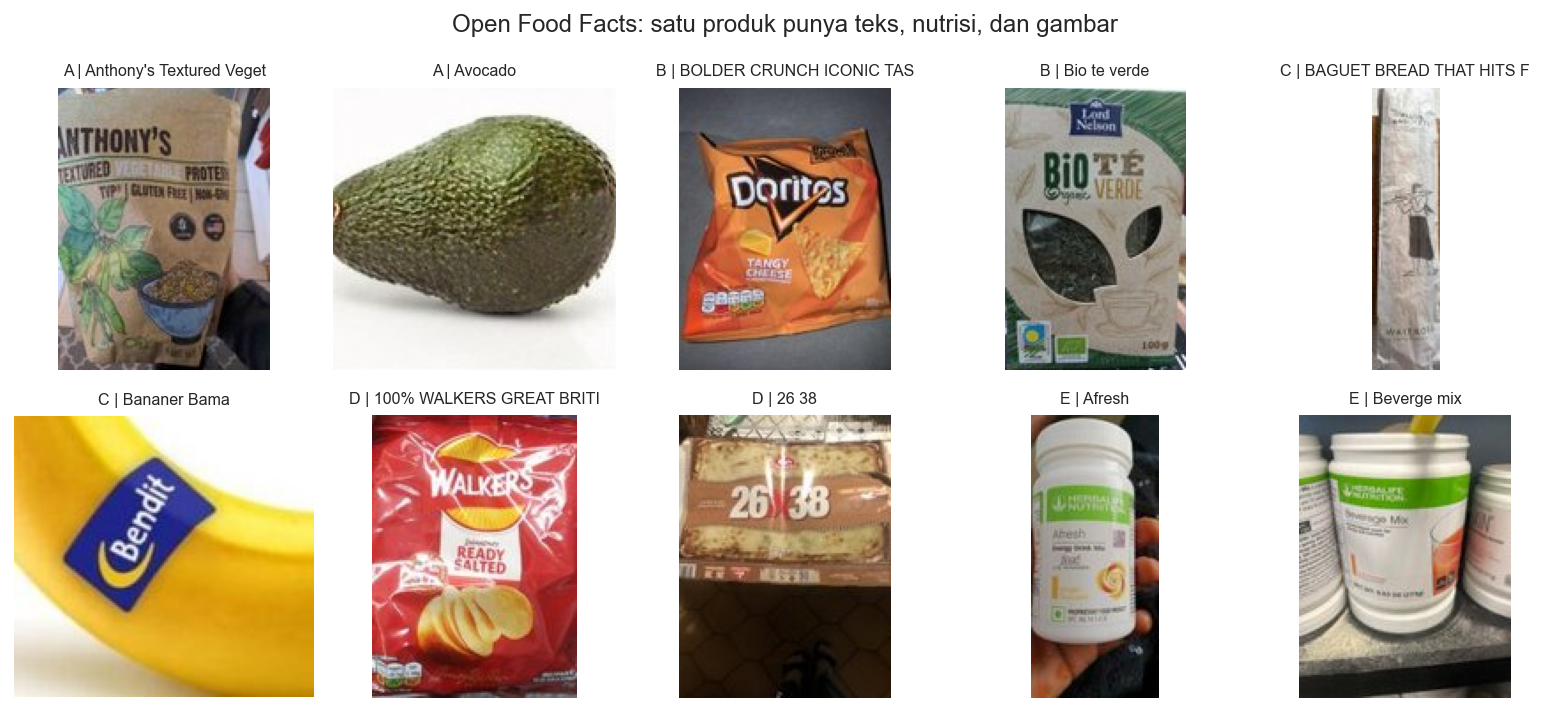

In [3]:
show = products.sort_values(['nutriscore_grade', 'product_name']).groupby('nutriscore_grade').head(2).head(10)
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, row in zip(axes.ravel(), show.itertuples(index=False)):
    img = Image.open(DATA_DIR / row.thumb_path)
    ax.imshow(img)
    title = f"{row.nutriscore_grade.upper()} | {str(row.product_name)[:24]}"
    ax.set_title(title, fontsize=8)
    ax.axis('off')
for ax in axes.ravel()[len(show):]:
    ax.axis('off')
plt.suptitle('Open Food Facts: satu produk punya teks, nutrisi, dan gambar')
plt.tight_layout()
plt.show()


## Modalitas tunggal vs fusi


         representation  average_precision  roc_auc     f1  accuracy
                   text             0.8025   0.8590 0.8372    0.8478
            image_color             0.7297   0.7105 0.6522    0.6522
      nutrition_tabular             0.9169   0.9124 0.7907    0.8043
late_tabular_plus_image             0.9191   0.9143 0.7907    0.8043
        text_plus_image             0.7515   0.7295 0.6522    0.6522
      text_plus_tabular             0.9108   0.9124 0.7907    0.8043
         all_modalities             0.8608   0.8571 0.7273    0.7391
Late-fusion weights: {'representation': 'late_tabular_plus_image', 'weight_selection': '5-fold train-only OOF average precision grid search', 'weight_tabular': 0.9500000000000001, 'weight_image': 0.04999999999999993, 'oof_average_precision': 0.9016542941810323}


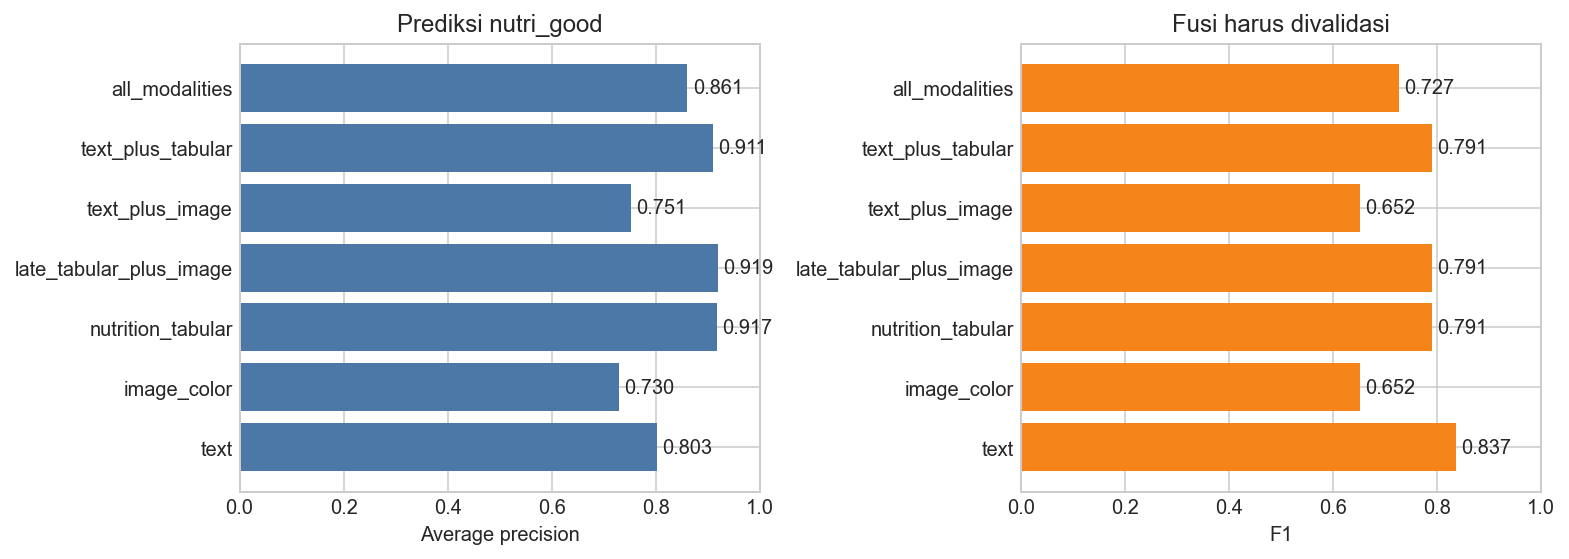

In [4]:
print(fusion.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('Late-fusion weights:', late_weights)
plot_order = ['text', 'image_color', 'nutrition_tabular', 'late_tabular_plus_image', 'text_plus_image', 'text_plus_tabular', 'all_modalities']
plot_df = fusion.set_index('representation').loc[plot_order].reset_index()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh(plot_df['representation'], plot_df['average_precision'], color='#4c78a8')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Average precision')
axes[0].set_title('Prediksi nutri_good')
for i, value in enumerate(plot_df['average_precision']):
    axes[0].text(value + 0.01, i, f'{value:.3f}', va='center')
axes[1].barh(plot_df['representation'], plot_df['f1'], color='#f58518')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('F1')
axes[1].set_title('Fusi harus divalidasi')
for i, value in enumerate(plot_df['f1']):
    axes[1].text(value + 0.01, i, f'{value:.3f}', va='center')
plt.tight_layout()
plt.show()


## Retrieval gambar ke teks


 test_pairs  image_to_text_recall_at_1  image_to_text_recall_at_5  image_to_text_recall_at_10  random_recall_at_5  cca_components
         46                     0.0435                     0.1739                      0.3043              0.1087              10


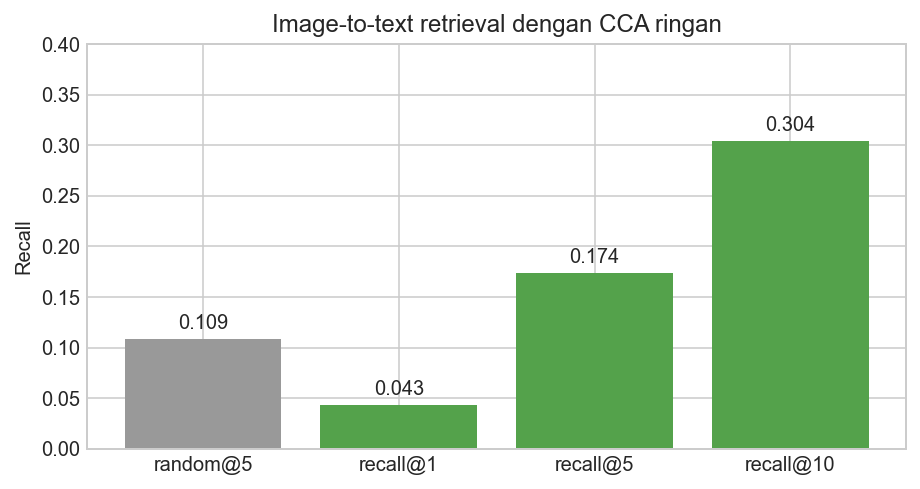

In [5]:
r = retrieval.iloc[0]
print(retrieval.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
recall_df = pd.DataFrame({
    'metric': ['random@5', 'recall@1', 'recall@5', 'recall@10'],
    'value': [r['random_recall_at_5'], r['image_to_text_recall_at_1'], r['image_to_text_recall_at_5'], r['image_to_text_recall_at_10']],
})
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(recall_df['metric'], recall_df['value'], color=['#999999', '#54a24b', '#54a24b', '#54a24b'])
ax.set_ylim(0, 0.4)
ax.set_ylabel('Recall')
ax.set_title('Image-to-text retrieval dengan CCA ringan')
for i, value in enumerate(recall_df['value']):
    ax.text(i, value + 0.01, f'{value:.3f}', ha='center')
plt.tight_layout()
plt.show()


>
> ?? **Amati.** Open Food Facts memang multimodal, tetapi fusi tetap harus divalidasi. Pada subset ini, late fusion tabular+gambar menjadi skor AP terbaik, namun bobot gambar yang dipilih dari data latih hanya 0.05. Fusi naif teks+gambar dan semua-modalitas tetap turun, jadi pesan utamanya adalah memilih strategi fusi dari validasi, bukan sekadar menggabungkan semua fitur. Bagian retrieval tetap menunjukkan sinyal pasangan gambar-teks di atas baseline acak, tetapi ini masih demo ringan, bukan sistem pencarian visual produksi.


## Section 2 - Mini Project

## Soal

Gunakan subset Open Food Facts yang sama untuk merancang strategi fusi yang lebih hati-hati.

Tugas:

1. Pakai `mini_products`, `image_feature_cols`, dan kolom teks/nutrisi dari sel di bawah.
2. Bandingkan minimal dua strategi: late fusion sederhana (rata-rata skor dua model) dan early fusion (gabungan fitur).
3. Jelaskan kapan modalitas gambar sebaiknya dipakai, diabaikan, atau diberi bobot kecil.

**Luaran:** tabel metrik dan 3-4 kalimat analisis.

**Kriteria penilaian:** (a) split train/test tidak dicampur; (b) label `nutriscore_grade` tidak dipakai sebagai fitur; (c) analisis menyebut bahwa modalitas lemah dapat merusak fusi.


In [6]:
# DATA AWAL (jangan diubah)
mini_products = products.copy()
image_feature_cols = [
    c for c in mini_products.columns
    if c.startswith(('r_', 'g_', 'b_', 'brightness_', 'dark_', 'light_', 'aspect_', 'image_'))
    and c not in {'image_small_url', 'image_url'}
]
text_columns = ['product_name', 'brands', 'categories', 'ingredients_text']
nutrition_columns = ['energy-kcal_100g','fat_100g','saturated-fat_100g','carbohydrates_100g','sugars_100g','fiber_100g','proteins_100g','salt_100g','sodium_100g']
print('Rows:', mini_products.shape, '| image features:', len(image_feature_cols))
mini_products[['split','product_name','nutriscore_grade','nutri_good','simple_category']].head()


Rows: (151, 206) | image features: 181


,split,product_name,nutriscore_grade,nutri_good,simple_category
0,test,Potato,b,1,cereal
1,train,Onion,a,1,sauce
2,train,Spinach,a,1,plant
3,train,Cucumber,a,1,plant
4,train,Mint leaves,a,1,sauce


In [7]:
# Kerjakan di sini.
# Petunjuk: mulai dari split mini_products['split']; bangun model terpisah untuk teks/nutrisi/gambar, lalu coba late fusion.
